In [ ]:
!pip install ultralytics split-folders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.1 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from ultralytics import YOLO
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
DRIVE_PATH     = "/content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/Cropped Dataset 3"
RAW_PATH       = "/content/raw_data"
BASE_DATA_PATH = "/content/yolo26_kfold"

if os.path.exists(DRIVE_PATH):
    if os.path.exists(RAW_PATH): shutil.rmtree(RAW_PATH)
    shutil.copytree(DRIVE_PATH, RAW_PATH)
    print("✅ Copied Data from Drive")
else:
    raise FileNotFoundError(f"Not found in Drive: {DRIVE_PATH}")

✅ Copied Data from Drive


In [ ]:
classes   = sorted([d for d in os.listdir(RAW_PATH) if os.path.isdir(os.path.join(RAW_PATH, d))])
all_files = []
for cls in classes:
    cls_path = os.path.join(RAW_PATH, cls)
    files = [os.path.join(cls, f) for f in os.listdir(cls_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_files.extend(files)

all_files = np.array(all_files)
print(f"📂 Classes: {classes}")
print(f"📂 Total images: {len(all_files)}")

K_FOLDS         = 5
kf              = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
overall_y_true  = []
overall_y_pred  = []
fold_accuracies = []

📂 Classes: ['class 0', 'class 1', 'class 2', 'class 3', 'class 4']
📂 Total images: 359


In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
    print(f"\n{'🌀'*20}")
    print(f"🔥 YOLO26 — FOLD {fold+1}/{K_FOLDS}")
    print(f"{'🌀'*20}")

    FOLD_PATH = f"{BASE_DATA_PATH}/fold_{fold+1}"
    if os.path.exists(FOLD_PATH): shutil.rmtree(FOLD_PATH)

    for split in ['train', 'val']:
        for cls in classes:
            os.makedirs(os.path.join(FOLD_PATH, split, cls), exist_ok=True)

    for f in all_files[train_idx]:
        shutil.copy(os.path.join(RAW_PATH, f), os.path.join(FOLD_PATH, 'train', f))
    for f in all_files[val_idx]:
        shutil.copy(os.path.join(RAW_PATH, f), os.path.join(FOLD_PATH, 'val', f))

    model = YOLO('yolo26n-cls.pt')
    model.train(
        data=FOLD_PATH,
        epochs=200,
        patience=20,           # ✅ early stopping จริงๆ (เดิมคือ 200 = ปิดอยู่)
        imgsz=224,
        batch=32,
        name=f'yolo26_fold_{fold+1}',
        device='0',
        exist_ok=True,
        verbose=True,

        # ── Augmentation — สู้ domain shift ──────────────────
        # Color/Brightness (สำคัญมาก — แสงกล้องต่างกัน)
        hsv_h=0.01,           # hue jitter เล็กน้อย 0.015
        hsv_s=0.3,             # saturation ± 50%  (เดิม default ~0.7 แต่เพิ่ม contrast) 0.5
        hsv_v=0.2,             # brightness ± 50%  ← ตัวนี้สำคัญสุด 0.5

        # Geometric (ช่วย generalize)
        degrees=15,            # หมุน ±15°
        translate=0.1,         # เลื่อน ±10%
        scale=0.3,             # zoom ±30%
        fliplr=0.5,            # flip แนวนอน 50%
        flipud=0.0,            # ไม่ flip แนวตั้ง (coffee bean มีทิศทาง)

        # Mixing augmentation
        mixup=0.1,             # mixup เบาๆ ช่วย regularize
        copy_paste=0.0,        # ไม่ใช้ (cls task)

        # ─────────────────────────────────────────────────────
        optimizer='AdamW',     # AdamW generalize ดีกว่า SGD บน dataset เล็ก
        lr0=0.001,
        weight_decay=0.0005,
        dropout=0.3,           # dropout ป้องกัน overfit (dataset เล็ก)
    )

    # ── Validate ─────────────────────────────────────────────
    best_path = f'runs/classify/yolo26_fold_{fold+1}/weights/best.pt'
    if os.path.exists(best_path):
        best_model = YOLO(best_path)

        val_img_paths = []
        for cls in classes:
            val_img_paths.extend(glob.glob(f"{FOLD_PATH}/val/{cls}/*"))

        results = best_model.predict(
            source=val_img_paths, imgsz=224, conf=0.0, verbose=False
        )

        fold_y_true = []
        fold_y_pred = []

        for i, r in enumerate(results):
            p_val    = r.probs.top1
            pred_idx = int(p_val.cpu().numpy()) if hasattr(p_val, 'cpu') else int(p_val)
            fold_y_pred.append(pred_idx)

            path_parts = os.path.normpath(val_img_paths[i]).split(os.sep)
            true_label = path_parts[-2]
            fold_y_true.append(classes.index(true_label))

        overall_y_true.extend(fold_y_true)
        overall_y_pred.extend(fold_y_pred)

        acc = (np.array(fold_y_true) == np.array(fold_y_pred)).mean()
        fold_accuracies.append(acc)
        print(f"✅ Fold {fold+1} Accuracy: {acc*100:.2f}%")


🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
🔥 YOLO26 — FOLD 1/5
🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀🌀
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo26_kfold/fold_1, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_fold_1, nbs=64, nms=False, opset


📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
🌟 สรุปผล CROSS VALIDATION (YOLO26 + Augmentation)
ค่าเฉลี่ย Accuracy: 86.62% ± 2.64%
   Fold 1: 90.28%
   Fold 2: 84.72%
   Fold 3: 86.11%
   Fold 4: 88.89%
   Fold 5: 83.10%
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊

📝 Overall Classification Report:
              precision    recall  f1-score   support

     class 0       0.91      0.91      0.91        75
     class 1       0.82      0.76      0.79        59
     class 2       0.84      0.76      0.80        70
     class 3       0.85      0.93      0.89        75
     class 4       0.89      0.94      0.91        80

    accuracy                           0.87       359
   macro avg       0.86      0.86      0.86       359
weighted avg       0.87      0.87      0.86       359



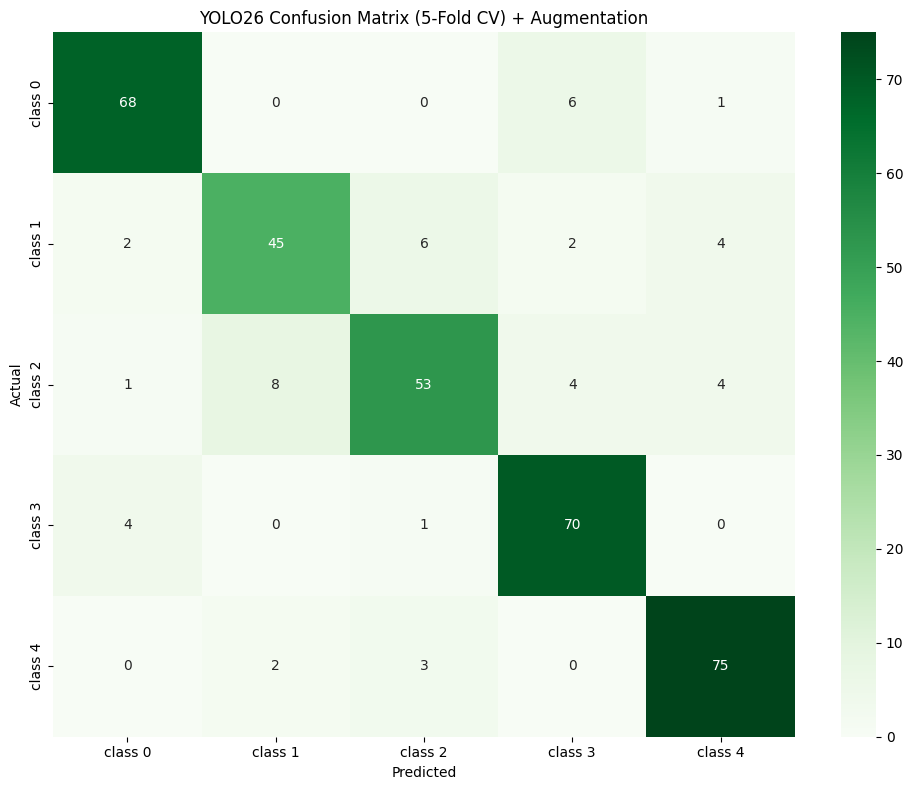

In [ ]:
print(f"\n{'📊'*15}")
print(f"🌟 สรุปผล CROSS VALIDATION (YOLO26 + Augmentation)")
print(f"ค่าเฉลี่ย Accuracy: {np.mean(fold_accuracies)*100:.2f}% ± {np.std(fold_accuracies)*100:.2f}%")
for i, a in enumerate(fold_accuracies):
    print(f"   Fold {i+1}: {a*100:.2f}%")
print(f"{'📊'*15}")

print("\n📝 Overall Classification Report:")
print(classification_report(overall_y_true, overall_y_pred, target_names=classes))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(overall_y_true, overall_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title(f'YOLO26 Confusion Matrix ({K_FOLDS}-Fold CV) + Augmentation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("confusion_matrix_yolo26_aug.png", dpi=150)
plt.show()

In [ ]:
best_fold     = int(np.argmax(fold_accuracies)) + 1
best_model_src = f"runs/classify/yolo26_fold_{best_fold}/weights/best.pt"
save_path      = "/content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/nownowyolo26cls_best_model.pt"
shutil.copy(best_model_src, save_path)
print(f"\n💾 Saved best model (Fold {best_fold}) → {save_path}")
print(f"   Best Fold Accuracy: {fold_accuracies[best_fold-1]*100:.2f}%")


💾 Saved best model (Fold 1) → /content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/nownowyolo26cls_best_model.pt
   Best Fold Accuracy: 90.28%
